# Phân tích mối quan hệ giữa cửa hàng và hiệu suất bán hàng


### Mục tiêu phân tích
- Câu hỏi 1: Phân tích mối quan hệ giữa mức độ uy tín của cửa hàng (store_rating, follower_count) với hiệu suất sản phẩm (sold_count, review_count, rating_avg) nhằm xác định vai trò của nhà bán hàng trong quyết định mua của khách hàng
- Câu hỏi 2: Đo lường ảnh hưởng của khuyến mãi lên hiệu suất bán và xem hiệu ứng khác nhau theo nhóm cửa hàng uy tín (store_rating/follower_count)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from datetime import timedelta
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.size": 11
})
pd.set_option("display.max_columns", None)


## Đọc dữ liệu (4 bảng)

In [2]:
df_products = pd.read_csv("../data/products.csv")
df_categories = pd.read_csv("../data/categories.csv")
df_stores = pd.read_csv("../data/stores.csv")
df_reviews = pd.read_csv("../data/reviews.csv")  # đồng bộ bộ dữ liệu; không dùng trực tiếp ở các bước dưới


## Làm sạch cơ bản

In [3]:
df_products = df_products.drop_duplicates(subset="product_id")
df_stores = df_stores.drop_duplicates(subset="store_id")
df_categories = df_categories.drop_duplicates(subset="category_id")

for col in ["price", "original_price", "discount_percent", "sold_count", "rating_avg", "review_count"]:
    if col in df_products.columns:
        df_products[col] = pd.to_numeric(df_products[col], errors="coerce")

for col in ["store_rating", "follower_count"]:
    if col in df_stores.columns:
        df_stores[col] = pd.to_numeric(df_stores[col], errors="coerce")

if "created_at" in df_products.columns:
    df_products["created_at"] = pd.to_datetime(df_products["created_at"], errors="coerce")

# lọc giá trị không hợp lệ
df_products = df_products[
    (df_products["sold_count"].fillna(0) >= 0) &
    (df_products["review_count"].fillna(0) >= 0) &
    (df_products["rating_avg"].fillna(0).between(0, 5)) &
    (df_products["price"].fillna(0) >= 0)
].copy()

df_stores = df_stores[
    (df_stores["store_rating"].fillna(0).between(0, 5)) &
    (df_stores["follower_count"].fillna(0) >= 0)
].copy()


## Ghép bảng

In [4]:
df_thuong_01 = df_products.merge(
    df_stores[["store_id", "store_name", "store_rating", "follower_count"]],
    on="store_id",
    how="left"
).merge(
    df_categories[["category_id", "category_name", "parent_category"]],
    on="category_id",
    how="left"
)


# Câu hỏi 1: Phân tích mối quan hệ giữa mức độ uy tín của cửa hàng (store_rating, follower_count) với hiệu suất sản phẩm (sold_count, review_count, rating_avg) nhằm xác định vai trò của nhà bán hàng trong quyết định mua của khách hàng

## Ghi chú chung về thiết kế & phạm vi dữ liệu
- Ý đồ thiết kế: loại các trường hợp “chưa phát sinh hoạt động” để tập trung vào nhóm sản phẩm/cửa hàng có tín hiệu thị trường.
- Dùng log1p cho các biến đếm (sold/review/follower) để nén thang đo và giảm ảnh hưởng outlier, giúp so sánh dễ hơn.
- Dùng Spearman (thay vì pearson) đo quan hệ đơn điệu và bền vững với phân phối lệch/outlier (phù hợp dữ liệu thương mại điện tử).

## Chuẩn bị tập phân tích insight (lọc + biến phụ)

In [5]:
# store_rating > 0, sold_count > 0, rating_avg > 0, follower_count > 0
df_insight = df_thuong_01[
    (df_thuong_01["store_rating"] > 0) &
    (df_thuong_01["sold_count"] > 0) &
    (df_thuong_01["rating_avg"] > 0) &
    (df_thuong_01["follower_count"] > 0)
].copy()

print(f"Số sản phẩm sau lọc (insight): {len(df_insight):,}")

df_insight["log_sold"] = np.log1p(df_insight["sold_count"])
df_insight["log_review"] = np.log1p(df_insight["review_count"])
df_insight["log_follower"] = np.log1p(df_insight["follower_count"])

df_insight["store_rating_group"] = pd.cut(
    df_insight["store_rating"],
    bins=[0, 4.0, 4.5, 4.8, 5.0],
    labels=["≤ 4.0", "4.0–4.5", "4.5–4.8", "4.8–5.0"],
    include_lowest=True
)

df_insight["follower_group"] = pd.qcut(
    df_insight["follower_count"].rank(method="first"),
    q=4,
    labels=["Q1 Ít follower", "Q2", "Q3", "Q4 Nhiều follower"]
)

store_agg = df_insight.groupby(
    ["store_id", "store_name", "store_rating", "follower_count"], as_index=False
).agg(
    total_sold=("sold_count", "sum"),
    total_reviews=("review_count", "sum"),
    avg_product_rating=("rating_avg", "mean"),
    num_products=("product_id", "count"),
    avg_sold_per_product=("sold_count", "mean")

)

store_agg["log_total_sold"] = np.log1p(store_agg["total_sold"])
store_agg["log_total_reviews"] = np.log1p(store_agg["total_reviews"])
store_agg["log_follower"] = np.log1p(store_agg["follower_count"])
store_agg["log_avg_sold"] = np.log1p(store_agg["avg_sold_per_product"])


print(f"Số cửa hàng (sau lọc insight): {len(store_agg):,}")


Số sản phẩm sau lọc (insight): 9,395
Số cửa hàng (sau lọc insight): 490


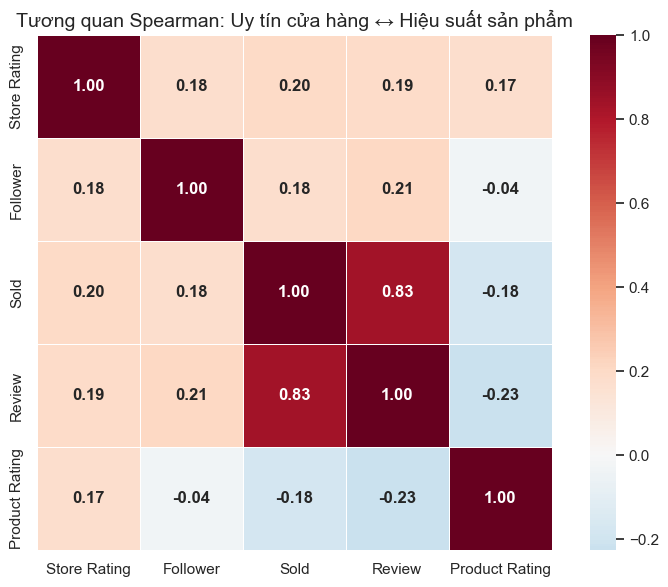

In [7]:
corr_df = df_insight[["store_rating", "follower_count", "sold_count", "review_count", "rating_avg"]].copy()
corr_df.columns = ["Store Rating", "Follower", "Sold", "Review", "Product Rating"]

corr_matrix = corr_df.corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    annot_kws={"fontsize": 12, "fontweight": "bold"}
)
plt.title("Tương quan Spearman: Uy tín cửa hàng ↔ Hiệu suất sản phẩm")
plt.tight_layout()
plt.show()




## Một số thiết kế quan trọng
- Lý do chọn tương quan spearman là do ít bị ảnh hưởng hơn bởi outlier và phân phối lệch, trong khi đó pearson đo quan hệ tuyến tính nhạy với phân phối lệch mạnh, outlier cực lớn ( một vài sản phẩm bán 20-50k, còn đa số bán 0-10) do đó dùng spearman phù hợp hơn trong bối cảnh thương mại điện từ.
## Nhận xét biểu đồ
- store_rating có tương quan dương nhẹ với: sold (~0.20), review (~0.19), product rating (~0.17)
- follower có tương quan dương nhẹ với: sold (~0.18), review (~0.21)
- follower gần như không liên quan đến product rating (~ -0.04)
## Insight
- Uy tín cửa hàng có liên hệ với hiệu suất sản phẩm, nhưng nhìn ở cấp “từng sản phẩm” thì mức tương quan thường không mạnh.
- follower_count thể hiện liên hệ rõ hơn với tương tác thị trường (số lượt bán và số đánh giá) hơn là với đánh giá chất lượng (product rating).
- store_rating liên hệ nhẹ với product rating, gợi ý cửa hàng được đánh giá cao thường gắn với trải nghiệm của người dùng đối với sản phẩm tốt hơn.


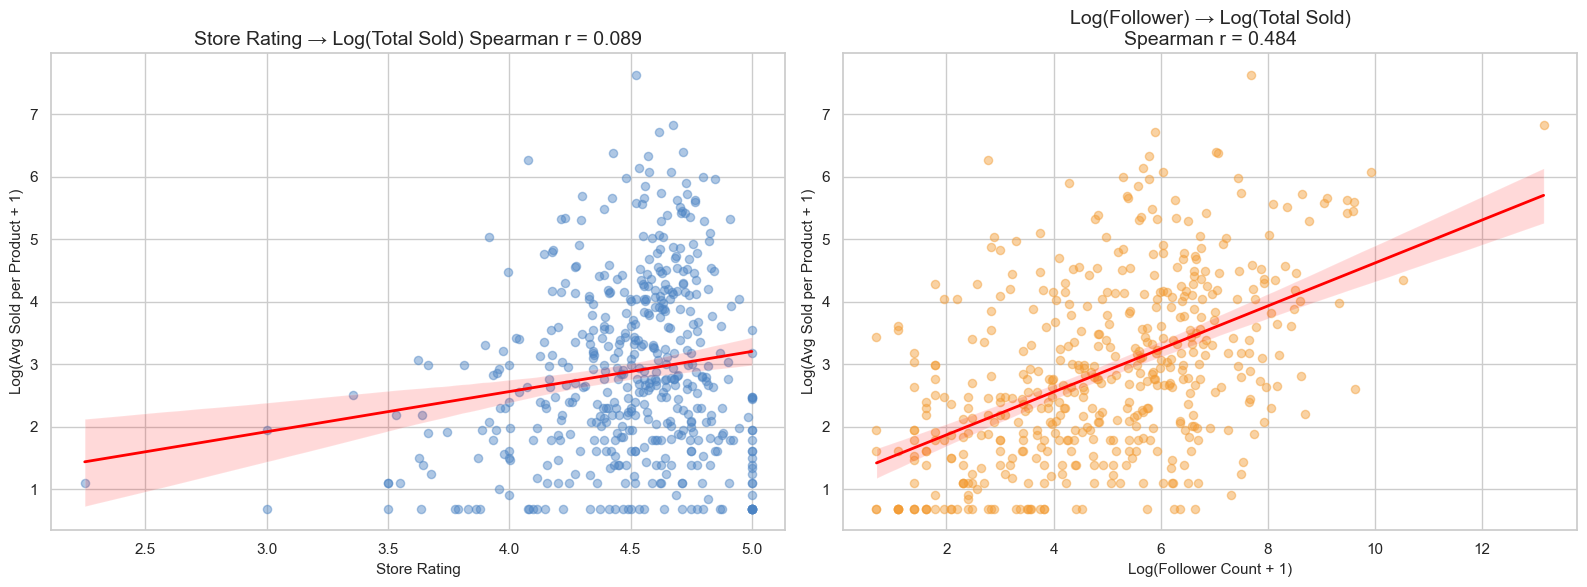

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

r_store_sold, _ = spearmanr(store_agg["store_rating"], store_agg["log_avg_sold"])
sns.regplot(
    data=store_agg,
    x="store_rating",
    y="log_avg_sold",
    scatter_kws={"alpha": 0.45, "s": 35, "color": "#4C84C4"},
    line_kws={"color": "red", "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title(f"Store Rating → Log(Total Sold) Spearman r = {r_store_sold:.3f}")
axes[0].set_xlabel("Store Rating")
axes[0].set_ylabel("Log(Avg Sold per Product + 1)")

r_follow_sold, _ = spearmanr(store_agg["log_follower"], store_agg["log_avg_sold"])
sns.regplot(
    data=store_agg,
    x="log_follower",
    y="log_avg_sold",
    scatter_kws={"alpha": 0.45, "s": 35, "color": "#F39C34"},
    line_kws={"color": "red", "linewidth": 2},
    ax=axes[1]
)
axes[1].set_title(f"Log(Follower) → Log(Total Sold)\nSpearman r = {r_follow_sold:.3f}")
axes[1].set_xlabel("Log(Follower Count + 1)")
axes[1].set_ylabel("Log(Avg Sold per Product + 1)")

plt.tight_layout()
plt.show()


## Một số thiết kế quan trọng
- Dùng trục y là trung bình số lượng bán được trên sản phẩm thay vì tổng sản phẩm để tránh kết luận sai kiểu shop bán tốt vì shop có nhiều sản phẩm
- Dùng log giúp quan sát xu hướng rõ hơn (đỡ dồn cụm ở gần 0).
## Nhận xét biểu đồ
- Store Rating tương quan hiệu suất bán (chuẩn hóa): Spearman r ≈ 0.089 → rất yếu
- Số lượng theo dõi cửa hàng (Follower) tương quan hiệu xuất bá (chuẩn hóa): Spearman r ≈ 0.484 → tương quan thuận 
khá rõ
- Biểu đồ Heatmap ở trước đang xem xét mức độ sản phẩm, còn biểu đồ scatter này đang xem ở mức độ cửa hàng
## Insight 
- follower_count là độ nhận diện gắn mạnh với hiệu suất bán, tức là vai trò nhà bán hàng (độ phổ biến/độ tin cậy) ảnh hưởng đáng kể đến quyết định mua.
- Store Rating gần như không giải thích tốt hiệu suất bán theo kiểu “rating càng cao bán càng nhiều”
- Heatmap (xét theo mức độ sản phẩm) cho thấy tương quan follower–sold chỉ ~0.18 (yếu), nhưng biểu đồ 2 (xét theo mức độ cửa hàng) cho thấy follower–sales mạnh hơn cho thấy rằng mức độ ảnh hưởng phụ thuộc vào cấp độ phân tích

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_122116\3365299978.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


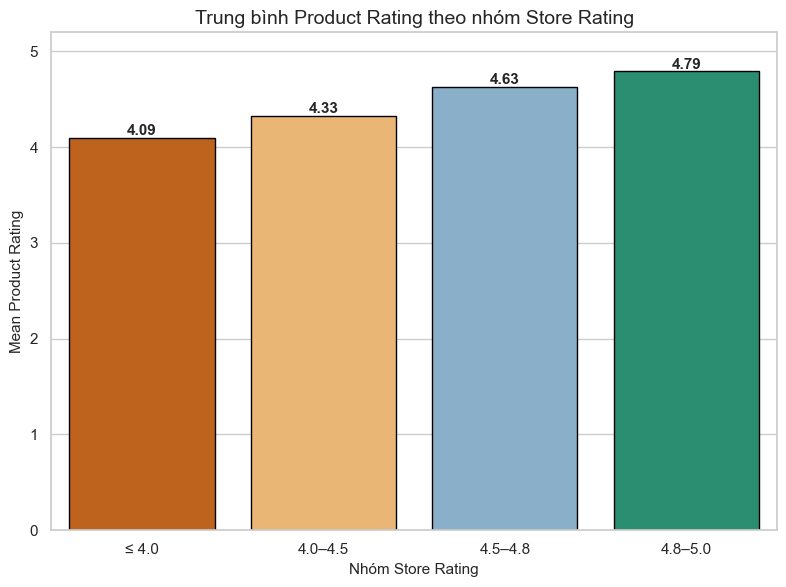

In [ ]:
grp_rating = df_insight.groupby("store_rating_group", observed=False).agg(
    mean_product_rating=("rating_avg", "mean"),
    median_sold=("sold_count", "median"),
    median_review=("review_count", "median")
).reset_index()

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=grp_rating,
    x="store_rating_group",
    y="mean_product_rating",
    palette=["#d95f02", "#fdb863", "#80b1d3", "#1b9e77"],
    edgecolor="black"
)

for i, v in enumerate(grp_rating["mean_product_rating"]):
    ax.text(i, v + 0.03, f"{v:.2f}", ha="center", fontweight="bold")

plt.title("Trung bình Product Rating theo nhóm Store Rating")
plt.xlabel("Nhóm Store Rating")
plt.ylabel("Mean Product Rating")
plt.ylim(0, 5.2)
plt.tight_layout()
plt.show()


## Nhận xét
- Trung bình đánh giá sản phẩm tăng đều theo nhóm store_rating
## Insight
- Dù store_rating không liên hệ mạnh với hiệu suất bán (biểu đồ 2), nó lại liên hệ rõ với “chất lượng cảm nhận” thông qua rating sản phẩm.
- Qua đó có thể thấy: Follower ảnh hưởng mạnh tới khả năng bán ,Store rating phản ánh chất lượng trải nghiệm – có thể ảnh hưởng gián tiếp (giữ chân, đánh giá tốt, uy tín dài hạn)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_122116\227949283.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


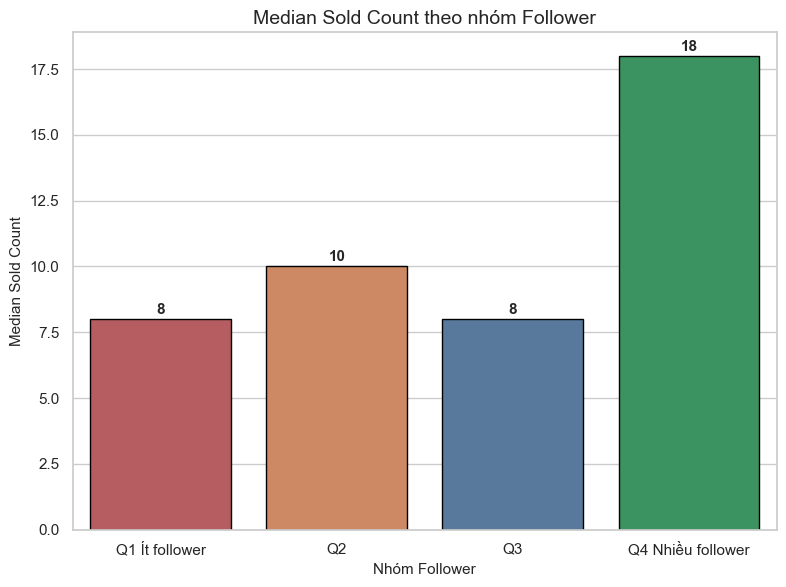

In [ ]:
grp_follower = df_insight.groupby("follower_group", observed=False).agg(
    median_sold=("sold_count", "median"),
    median_review=("review_count", "median"),
    mean_product_rating=("rating_avg", "mean")
).reset_index()

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=grp_follower,
    x="follower_group",
    y="median_sold",
    palette=["#c44e52", "#dd8452", "#4c78a8", "#2ca25f"],
    edgecolor="black"
)

for i, v in enumerate(grp_follower["median_sold"]):
    ax.text(i, v + 0.2, f"{v:.0f}", ha="center", fontweight="bold")

plt.title("Median Sold Count theo nhóm Follower")
plt.xlabel("Nhóm Follower")
plt.ylabel("Median Sold Count")
plt.tight_layout()
plt.show()


## Nhận xét:
- Tuy không có sự tăng dần đều giữa các nhóm nhưng nhóm follower cao nhất (Q4) có median sold cao nhất (18), cao hơn các nhóm còn lại (8–10).
## Insight
- Biểu đồ này nhằm củng cố kết luận từ biểu đồ 2:  follower_count là một độ nhận diện có liên hệ mạnh với hiệu suất bán.Ngoài ra việc dùng median giúp tránh trường hợp một vài sản phẩm “siêu bán chạy” làm méo kết quả.

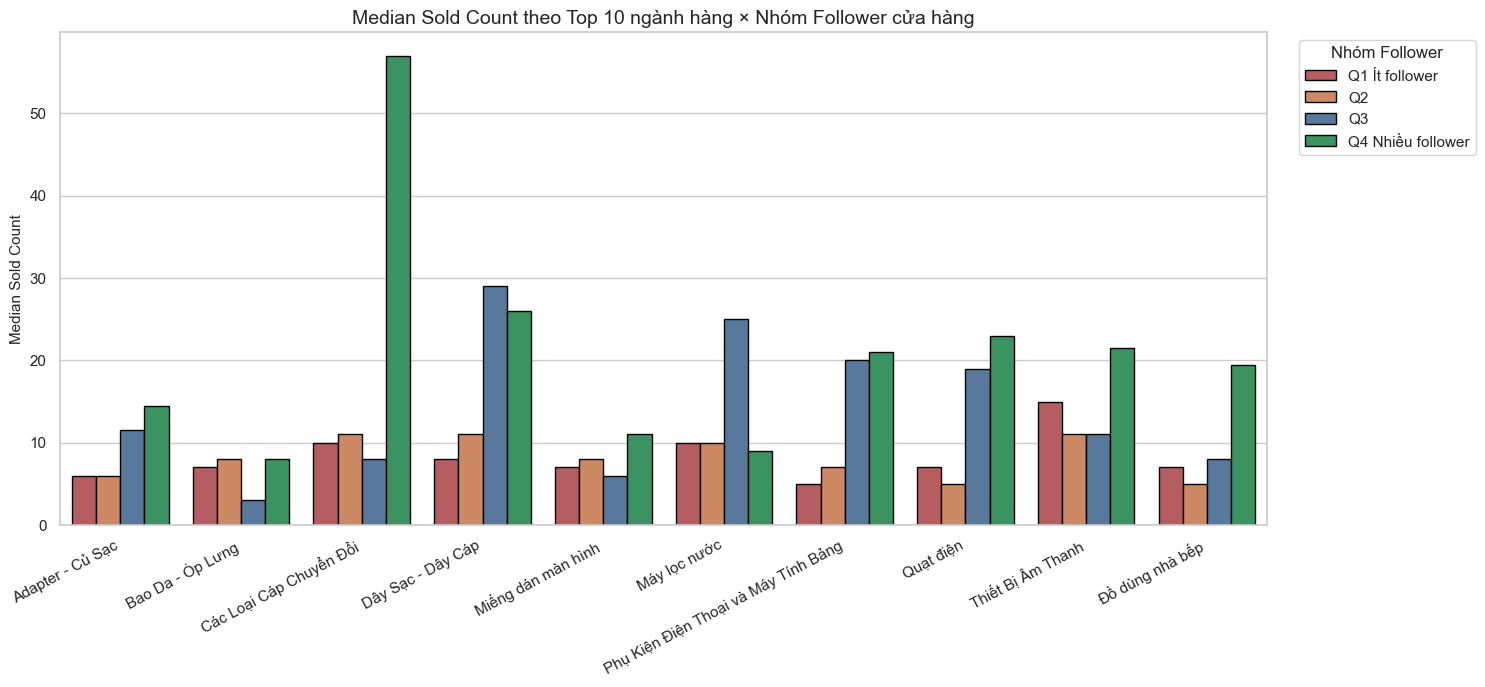

In [ ]:
top10_categories = df_insight["parent_category"].value_counts().head(10).index.tolist()
df_top = df_insight[df_insight["parent_category"].isin(top10_categories)].copy()

cat_summary = df_top.groupby(
    ["parent_category", "follower_group"], observed=False
).agg(
    median_sold=("sold_count", "median")
).reset_index()

plt.figure(figsize=(15, 7))
sns.barplot(
    data=cat_summary,
    x="parent_category",
    y="median_sold",
    hue="follower_group",
    palette=["#c44e52", "#dd8452", "#4c78a8", "#2ca25f"],
    edgecolor="black"
)
plt.title("Median Sold Count theo Top 10 ngành hàng × Nhóm Follower cửa hàng")
plt.xlabel("")
plt.ylabel("Median Sold Count")
plt.xticks(rotation=28, ha="right")
plt.legend(title="Nhóm Follower", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Nhận xét:
- Trong nhiều ngành hàng, nhóm follower cao (Q4) thường có median sold cao hơn.
- Tuy nhiên mức độ chênh lệch không giống nhau giữa các ngành; có ngành chênh rất mạnh, có ngành chênh ít hoặc không đều.
## Insight
- Vai trò của uy tín cửa hàng (đặc biệt follower) phụ thuộc vào ngành hàng.
- Hành vi mua hàng sẽ khác nhau giữa các nhóm sản phẩm, người bán ít follower có thể sẽ cân nhắc tránh bán các mặt hàng có các cửa hàng có nhiều follower thống trị như "Các loại cáp chuyển đổi" mà có thể cân nhắc bán các mặt hàng vẫn có tỉ lệ cạnh tranh với các nhóm khác như "Thiết bị âm thanh"


## Kết luận tóm tắt
- Độ nhận diện/quy mô tệp theo dõi phản ánh sức ảnh hưởng của nhà bán hàng và có thể làm giảm rủi ro cảm nhận → tăng khả năng mua.
- store_rating phản ánh chất lượng dịch vụ/độ hài lòng, có thể ảnh hưởng gián tiếp đến uy tín dài hạn (đánh giá tốt, mua lại), hơn là tạo doanh số ngay lập tức.
- Vai trò nhà bán hàng phụ thuộc vào bối cảnh ngành hàng (mức độ rủi ro sản phẩm,cạnh tranh giá…).

## Lời khuyên theo đối tượng
### 1) Đối với cửa hàng có follower thấp (shop mới/ít nhận diện)
- Ưu tiên chiến lược tăng follower vì đây là biến gắn mạnh với hiệu suất bán: Chương trình “Follow shop nhận voucher”,live/short-video, affiliate/KOL nhỏ
- Không nên chỉ “đốt” giảm giá để kéo doanh số nếu chưa có độ tin cậy, vì người mua công nghệ thường nhạy với rủi ro thiếu tin tưởng sẽ khó chuyển đổi.
### 2) Đối với cửa hàng có follower cao
- Tận dụng lợi thế nhận diện để: Mở rộng danh mục sản phẩm bán chạy, đẩy mạnh các chiến dịch ra mắt sản phẩm mới (niềm tin sẵn có giúp chuyển đổi nhanh)
### 3) Đối với người mua
- Nếu mục tiêu là giảm rủi ro, có thể ưu tiên: shop có follower cao (độ phổ biến) + rating tốt,
sản phẩm có nhiều review.
- Tuy nhiên vẫn nên kiểm tra đánh giá gần đây và chính sách bảo hành (đặc biệt với hàng công nghệ).


# Mục tiêu 2: Đo lường ảnh hưởng của khuyến mãi lên hiệu suất bán và xem hiệu ứng khác nhau theo nhóm cửa hàng uy tín (store_rating/follower_count)

## Ghi chú thiết kế chung
- Chia mức khuyến mãi theo bin (0–10%, 11–30%, >30%) để chuyển bài toán “liên tục” sang “so sánh nhóm”, dễ quan sát xu hướng và trình bày insight.
- Dùng log1p(sold_count) và lấy median: sold_count thường lệch phải và có outlier rất lớn → median + log giúp kết quả ổn định, tránh bị một vài sản phẩm bán “khủng” làm méo.
- Hiển thị số lượng mẫu (n): Giúp đánh giá độ tin cậy của từng ô/nhóm, tránh kết luận dựa trên nhóm ít dữ liệu.


In [ ]:
DAYS_BACK = 90
MIN_CELL_N = 100  # ngưỡng n tối thiểu cho từng ô (Discount × Group)

DISCOUNT_ORDER = ["Thấp (0-10%)", "Trung bình (11-30%)", "Cao (>30%)"]
FOLLOWER_ORDER = ["Follower thấp", "Follower trung bình", "Follower cao"]
RATING_ORDER = ["Rating thấp (≤4.0)", "Rating trung bình (4.0-4.5)", "Rating cao (>4.5)"]

plt.rcParams.update({"figure.figsize": (12, 6), "axes.titlesize": 13})


## Chuẩn bị tập dữ liệu

In [ ]:
df_discount = df_thuong_01.copy()



df_discount = df_discount[
    (df_discount["sold_count"] > 0) &
    (df_discount["discount_percent"].notna()) & (df_discount["discount_percent"] >= 0) &
    (df_discount["store_rating"].notna()) & (df_discount["store_rating"] > 0) &
    (df_discount["follower_count"].notna()) & (df_discount["follower_count"] > 0)
].copy()

df_discount["log_sold"] = np.log1p(df_discount["sold_count"])
df_discount["discount_percent"] = df_discount["discount_percent"].clip(0, 100)

df_discount["discount_bin"] = pd.cut(
    df_discount["discount_percent"],
    bins=[-1, 10, 30, 100],
    labels=DISCOUNT_ORDER
)

df_discount["follower_group"] = pd.qcut(
    df_discount["follower_count"].rank(method="first"),
    q=3,
    labels=FOLLOWER_ORDER
)

df_discount["rating_group"] = pd.cut(
    df_discount["store_rating"],
    bins=[0, 4.0, 4.5, 5.0],
    labels=RATING_ORDER,
    include_lowest=True
)

df_discount = df_discount[
    df_discount["discount_bin"].notna() & df_discount["follower_group"].notna() & df_discount["rating_group"].notna()
].copy()

df_discount["discount_bin"] = pd.Categorical(df_discount["discount_bin"], categories=DISCOUNT_ORDER, ordered=True)
df_discount["follower_group"] = pd.Categorical(df_discount["follower_group"], categories=FOLLOWER_ORDER, ordered=True)
df_discount["rating_group"] = pd.Categorical(df_discount["rating_group"], categories=RATING_ORDER, ordered=True)


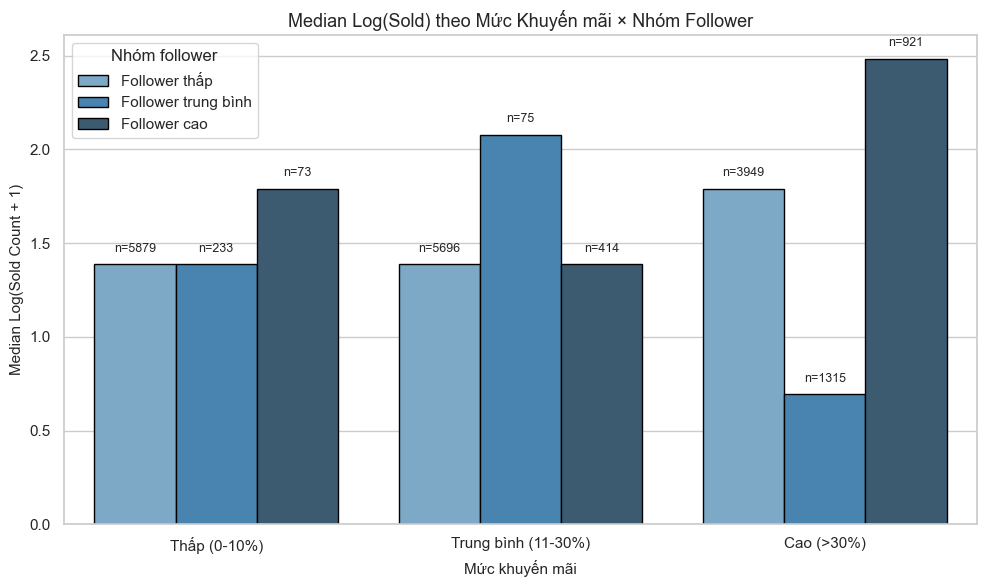

In [ ]:
def annotate_n_from_lookup(ax, x_order, hue_order, n_lookup, y_pad=0.02, fontsize=9):
    combos = [(x, h) for x in x_order for h in hue_order]
    patches = [p for p in ax.patches if p.get_width() > 0]
    m = min(len(patches), len(combos))
    y_max = max([p.get_height() for p in patches[:m]] + [0])

    for i in range(m):
        x, h = combos[i]
        p = patches[i]
        n = int(n_lookup.get((x, h), 0))
        ax.text(
            p.get_x() + p.get_width() / 2,
            p.get_height() + (y_max * y_pad),
            f"n={n}",
            ha="center", va="bottom",
            fontsize=fontsize
        )


cell_f = (df_discount.groupby(["discount_bin", "follower_group"], observed=False)
            .agg(median_log_sold=("log_sold", "median"),
                 n=("log_sold", "size"))
            .reset_index())

n_lookup_f = {(r["discount_bin"], r["follower_group"]): r["n"] for _, r in cell_f.iterrows()}

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=cell_f,
    x="discount_bin", y="median_log_sold",
    hue="follower_group",
    order=DISCOUNT_ORDER, hue_order=FOLLOWER_ORDER,
    palette="Blues_d", edgecolor="black",
    errorbar=None
)
plt.title("Median Log(Sold) theo Mức Khuyến mãi × Nhóm Follower")
plt.xlabel("Mức khuyến mãi")
plt.ylabel("Median Log(Sold Count + 1)")
plt.legend(title="Nhóm follower", loc="upper left")
annotate_n_from_lookup(ax, DISCOUNT_ORDER, FOLLOWER_ORDER, n_lookup_f)
plt.tight_layout()
plt.show()


## Nhận xét: 
- Nhìn chung thì nhóm cửa hàng có follower cao thì đạt median log(sold) cao hơn ở nhiều mức khuyến mãi.
- Ở mức khuyến mãi cao (>30%), nhóm Follower cao có median log(sold) cao nhất (2.48, n=921)
- Cũng cần lưu ý đối với Follower thấp × Discount cao và Follower trung bình × Discount trung bình do mẫu khá ít, không nên kết luật mạnh
## Insight 
- Các shop có độ nhận diện cao có khả năng “chuyển hóa” khuyến mãi thành doanh số tốt hơn.


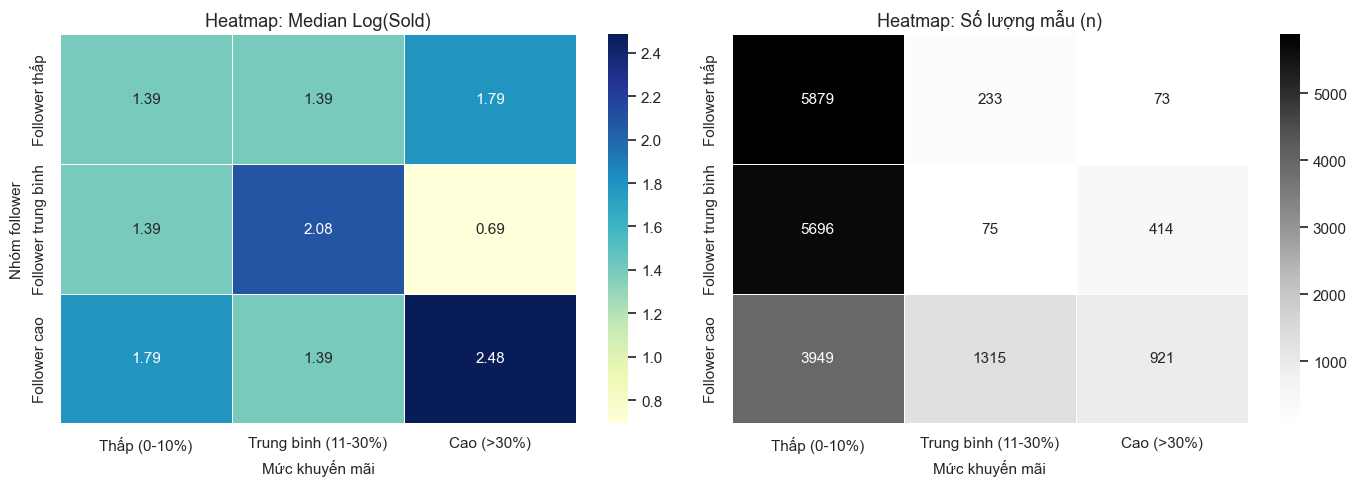

In [ ]:
pivot_median = cell_f.pivot(index="follower_group", columns="discount_bin", values="median_log_sold").reindex(FOLLOWER_ORDER)
pivot_n = cell_f.pivot(index="follower_group", columns="discount_bin", values="n").reindex(FOLLOWER_ORDER)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    pivot_median, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5,
     ax=axes[0]
)
axes[0].set_title(f"Heatmap: Median Log(Sold)")
axes[0].set_xlabel("Mức khuyến mãi")
axes[0].set_ylabel("Nhóm follower")

sns.heatmap(
    pivot_n, annot=True, fmt=".0f", cmap="Greys", linewidths=0.5, ax=axes[1]
)
axes[1].set_title("Heatmap: Số lượng mẫu (n)")
axes[1].set_xlabel("Mức khuyến mãi")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()





## Nhận xét:
- Biểu đồ heatmap củng cố độ chắc chắn: thay vì nhìn barplot rời rạc thì biểu đồ này có thể nhìn toàn bộ ma trận Discount × Follower, ngoài ra có thể đồng thời kiểm tra mẫu đủ lớn hay không bằng heatmap n
- Các ô tương quan cao nhưng có thể không đủ độ tin cậy do số mẫu ít (< 100): nhóm mức khuyến mãi trung bình x follower trung bình (2.08) và nhóm mức khuyến mãi cao và Follower thấp (1.79)
- Các ô tương quan cao và có đủ mẫu để kết luận đáng tin cậy: Nhóm khuyến mãi cao x Follower Cao (2.48) và nhóm khuyến mãi thấp và Follower cao (1.79)
## Insight
- Khuyến mãi sâu kết hợp shop nhiều follower đi kèm hiệu suất bán tốt hơn.


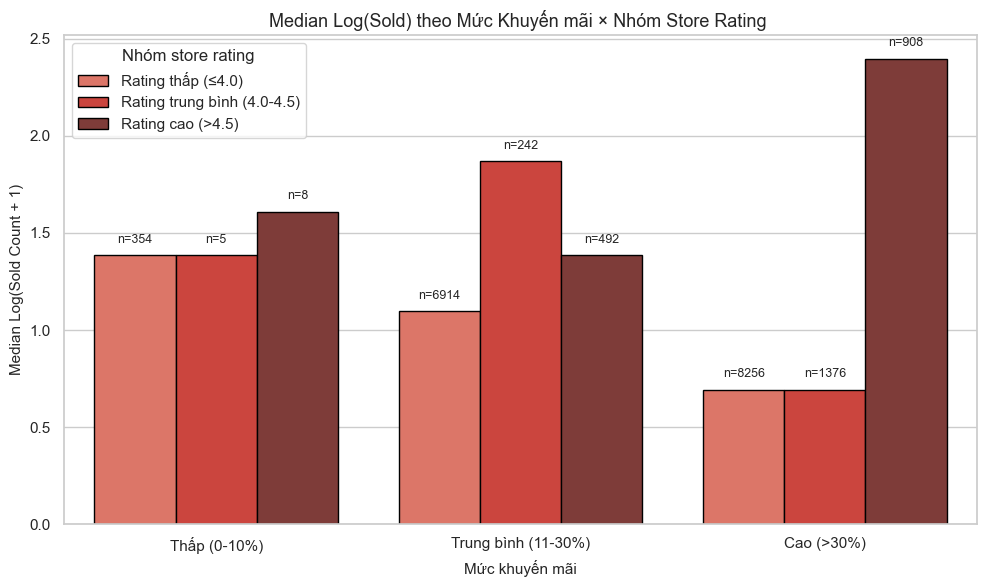

In [ ]:
cell_r = (df_discount.groupby(["discount_bin", "rating_group"], observed=False)
            .agg(median_log_sold=("log_sold", "median"),
                 n=("log_sold", "size"))
            .reset_index())

n_lookup_r = {(r["discount_bin"], r["rating_group"]): r["n"] for _, r in cell_r.iterrows()}

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=cell_r,
    x="discount_bin", y="median_log_sold",
    hue="rating_group",
    order=DISCOUNT_ORDER, hue_order=RATING_ORDER,
    palette="Reds_d", edgecolor="black",
    errorbar=None
)
plt.title("Median Log(Sold) theo Mức Khuyến mãi × Nhóm Store Rating ")
plt.xlabel("Mức khuyến mãi")
plt.ylabel("Median Log(Sold Count + 1)")
plt.legend(title="Nhóm store rating", loc="upper left")
annotate_n_from_lookup(ax, DISCOUNT_ORDER, RATING_ORDER, n_lookup_r)
plt.tight_layout()
plt.show()


## Nhận xét
- 2 biểu đồ trước đã đánh giá được mức khuyến mãi kết hợp với tiêu chí follower, biểu đồ này sẽ xem xét về khía cạnh mức khuyến mãi và Store Rating
- Ở mức khuyến mãi cao (>30%), nhóm Rating cao (>4.5) có median log(sold) rất cao (~2.4, n=908), trong khi hai nhóm rating thấp/trung bình thấp hơn rõ.
- Một số cột ở discount thấp có n cực nhỏ (ví dụ rating trung bình n=5, rating cao n=8) không nên kết luận dựa vào các cột này.
## Insight
- Store rating cao có thể giúp tăng hiệu quả của khuyến mãi (tăng niềm tin, giảm rủi ro cảm nhận, giúp khách hàng ra quyết định nhanh hơn khi thấy giảm giá)

## Kết luận tóm tắt
Phân tích cho thấy khuyến mãi có liên hệ tích cực với hiệu suất bán (sold_count), và mức độ “hiệu quả” của khuyến mãi thay đổi theo uy tín cửa hàng:

- Nhóm cửa hàng uy tín cao (đặc biệt theo follower_count) đạt median log(sold) cao nhất ở mức khuyến mãi cao (>30%). 
- Store rating cao (>4.5) cũng cho thấy hiệu suất bán tốt hơn rõ rệt ở khuyến mãi cao, tuy nhiên một số nhóm ở mức khuyến mãi thấp có cỡ mẫu nhỏ, nên kết luận với rating cần diễn giải cẩn trọng hơn so với follower.
- Việc hiển thị n: không phải mọi tổ hợp (discount × uy tín) đều đủ dữ liệu để kết luận chắc chắn; các kết luận mạnh nên dựa vào các ô có n lớn (ví dụ discount cao & follower cao).
- Tóm lại: Uy tín nhà bán hàng đóng vai trò “khuếch đại” hiệu quả khuyến mãi—khuyến mãi sâu thường “chuyển hóa” thành doanh số tốt hơn ở các shop uy tín cao.

## Lời khuyên theo từng đối tượng
### 1) Đối với cửa hàng có follower cao / rating cao
- Có thể tận dụng khuyến mãi sâu (>30%) như một “đòn bẩy tăng trưởng” vì dữ liệu gợi ý hiệu quả chuyển đổi cao hơn.
- Nên ưu tiên các chiến dịch: flash sale/mega sale cho nhóm sản phẩm chủ lực
- Theo dõi thêm review_count và tỉ lệ đánh giá tiêu cực khi chạy giảm sâu (tránh “bán nhiều nhưng giảm chất lượng trải nghiệm”).
### 2) Đối với cửa hàng follower thấp / rating thấp
- Không nên phụ thuộc vào giảm sâu ngay từ đầu như chiến lược chính, vì một số nhóm có n nhỏ, và hiệu quả không ổn định theo dữ liệu quan sát
- Khuyến nghị chiến lược “xây uy tín trước – tăng khuyến mãi sau”: tập trung cải thiện rating shop (CSKH, đổi trả,đóng gói, giao hàng), tăng follower bằng voucher follow shop, live/affiliate, nội dung sản phẩm rõ ràng
